In [3]:
%pip install matplotlib

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------------------- -------------------- 3.9/8.2 MB 19.5 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.2 MB 11.4 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.2 MB 8.8 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.2 MB 7.2 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.2 MB 6.5 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.2 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 5.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.3 MB ? eta -:--:--
   ---------------------- ----------------- 1.3/2.3 MB 3.0 MB/s eta 0:00:01
   ----------------------------------- ---- 2.1/2.3 MB 3.2 MB/s eta 0:00:01
   ----------------------------


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

In [107]:
df = pd.read_csv("imdb_movies.csv")

In [108]:
df.head()

,movie_id,title,genre,rating,budget_million,gross_million,director,lead_actor,release_year
0,1.0,Movie 1,Thriller,4.2,100.0,NaN,Cameron,NaN,2017.0
1,2.0,Movie 2,Sci-Fi,7.8,150.0,150.0,Nolan,Actor B,2019.0
2,3.0,Movie 3,Thriller,4.9,30.0,600.0,Spielberg,Actor D,2016.0
3,4.0,Movie 4,Thriller,9.1,100.0,600.0,Rajamouli,Actor D,2015.0
4,5.0,Movie 5,Sci-Fi,4.5,10.0,600.0,Cameron,Actor C,2022.0


In [9]:
df.shape

(5500, 9)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   movie_id        5177 non-null   float64
 1   title           5500 non-null   str    
 2   genre           5500 non-null   str    
 3   rating          5211 non-null   float64
 4   budget_million  4569 non-null   float64
 5   gross_million   4583 non-null   float64
 6   director        4720 non-null   str    
 7   lead_actor      4586 non-null   str    
 8   release_year    4886 non-null   float64
dtypes: float64(5), str(4)
memory usage: 386.8 KB


In [11]:
df.columns

Index(['movie_id', 'title', 'genre', 'rating', 'budget_million',
       'gross_million', 'director', 'lead_actor', 'release_year'],
      dtype='str')

In [12]:
df.isnull().sum()

movie_id          323
title               0
genre               0
rating            289
budget_million    931
gross_million     917
director          780
lead_actor        914
release_year      614
dtype: int64

In [13]:
(df.isnull().sum()/len(df))*100

movie_id           5.872727
title              0.000000
genre              0.000000
rating             5.254545
budget_million    16.927273
gross_million     16.672727
director          14.181818
lead_actor        16.618182
release_year      11.163636
dtype: float64

In [15]:
df['budget_million'].fillna(
    df['budget_million'].median(),
    inplace=True
)

df['gross_million'].fillna(
    df['gross_million'].median(),
    inplace=True
)

C:\Users\mdsuh\AppData\Local\Temp\ipykernel_24076\3129277553.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['budget_million'].fillna(
C:\Users\mdsuh\AppData\Local\Temp\ipykernel_24076\3129277553.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace me

0       150.0
1       150.0
2       600.0
3       600.0
4       600.0
        ...  
5495     80.0
5496     20.0
5497     80.0
5498    600.0
5499     20.0
Name: gross_million, Length: 5500, dtype: float64

In [84]:
df['budget_million'] = df['budget_million'].fillna(
    df['budget_million'].median()
)

df['gross_million'] = df['gross_million'].fillna(
    df['gross_million'].median()
)

In [85]:
print(df.isnull().sum())

movie_id          323
title               0
genre               0
rating            289
budget_million      0
gross_million       0
director          780
lead_actor        914
release_year      614
dtype: int64


In [18]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   movie_id        5177 non-null   float64
 1   title           5500 non-null   str    
 2   genre           5500 non-null   str    
 3   rating          5211 non-null   float64
 4   budget_million  5500 non-null   float64
 5   gross_million   5500 non-null   float64
 6   director        4720 non-null   str    
 7   lead_actor      4586 non-null   str    
 8   release_year    4886 non-null   float64
dtypes: float64(5), str(4)
memory usage: 386.8 KB


In [20]:
df.describe()

,movie_id,rating,budget_million,gross_million,release_year
count,5177.000000,5211.00000,5500.000000,5500.000000,4886.000000
mean,2750.281630,6.50641,67.536364,216.183636,2018.492223
std,1588.028767,1.73132,45.325032,192.004290,2.296863
min,1.000000,3.50000,10.000000,20.000000,2015.000000
25%,1375.000000,5.00000,30.000000,80.000000,2016.000000
50%,2750.000000,6.50000,60.000000,150.000000,2018.000000
75%,4125.000000,8.00000,100.000000,300.000000,2021.000000
max,5500.000000,9.50000,150.000000,600.000000,2022.000000


In [87]:
top_gross = df.sort_values(
    by='gross_million',
    ascending=False
)

top_gross[['title','gross_million']].head(10)

,title,gross_million
1819,Movie 1820,600.0
34,Movie 35,600.0
37,Movie 38,600.0
69,Movie 70,600.0
4730,Movie 4731,600.0
4734,Movie 4735,600.0
4739,Movie 4740,600.0
4743,Movie 4744,600.0
5,Movie 6,600.0
2,Movie 3,600.0


In [99]:
df = df.sort_values(
    by=['title',
        'release_year',
        'rating',
        'gross_million'],
    ascending=[True,True,False,False]
)

df = df.drop_duplicates(
    subset=['title','release_year'],
    keep='first'
)
df["rating"].head(10)
df

,movie_id,title,genre,rating,budget_million,gross_million,director,lead_actor,release_year
0,1001,Movie 1,Thriller,4.2,100.0,150.0,Cameron,NaN,2017.0
9,1002,Movie 10,Sci-Fi,5.0,60.0,20.0,Spielberg,Actor B,2019.0
1000,1003,Movie 1001,Comedy,6.4,60.0,20.0,Rajamouli,Actor D,2021.0
1001,1004,Movie 1002,Comedy,7.6,60.0,150.0,Cameron,NaN,NaN
1002,1005,Movie 1003,Sci-Fi,9.1,150.0,150.0,Spielberg,Actor C,2019.0
...,...,...,...,...,...,...,...,...,...
995,6469,Movie 996,Drama,4.5,150.0,80.0,Cameron,Actor B,2020.0
996,6470,Movie 997,Horror,6.3,150.0,300.0,Unknown,Actor B,2019.0
997,6471,Movie 998,Romance,6.9,10.0,150.0,Nolan,Actor B,2022.0
999,6472,Movie 999,Horror,8.0,10.0,600.0,Tarantino,Actor A,2019.0


In [100]:
df["rating"].head(10)
df

,movie_id,title,genre,rating,budget_million,gross_million,director,lead_actor,release_year
0,1001,Movie 1,Thriller,4.2,100.0,150.0,Cameron,NaN,2017.0
9,1002,Movie 10,Sci-Fi,5.0,60.0,20.0,Spielberg,Actor B,2019.0
1000,1003,Movie 1001,Comedy,6.4,60.0,20.0,Rajamouli,Actor D,2021.0
1001,1004,Movie 1002,Comedy,7.6,60.0,150.0,Cameron,NaN,NaN
1002,1005,Movie 1003,Sci-Fi,9.1,150.0,150.0,Spielberg,Actor C,2019.0
...,...,...,...,...,...,...,...,...,...
995,6469,Movie 996,Drama,4.5,150.0,80.0,Cameron,Actor B,2020.0
996,6470,Movie 997,Horror,6.3,150.0,300.0,Unknown,Actor B,2019.0
997,6471,Movie 998,Romance,6.9,10.0,150.0,Nolan,Actor B,2022.0
999,6472,Movie 999,Horror,8.0,10.0,600.0,Tarantino,Actor A,2019.0


In [89]:
df['movie_id'] = range(
    1001,
    1001 + len(df)
)

In [90]:
df['rating'] = df.groupby(
    'genre'
)['rating'].transform(
    lambda x: x.fillna(x.mean())
)

df['rating'] = df['rating'].fillna(
    df['rating'].mean()
)

In [91]:
df['director'] = df['director'].fillna(
    'Unknown'
)

In [80]:
df['lead_actor'] = df['lead_actor'].fillna(
    'Unknown'
)

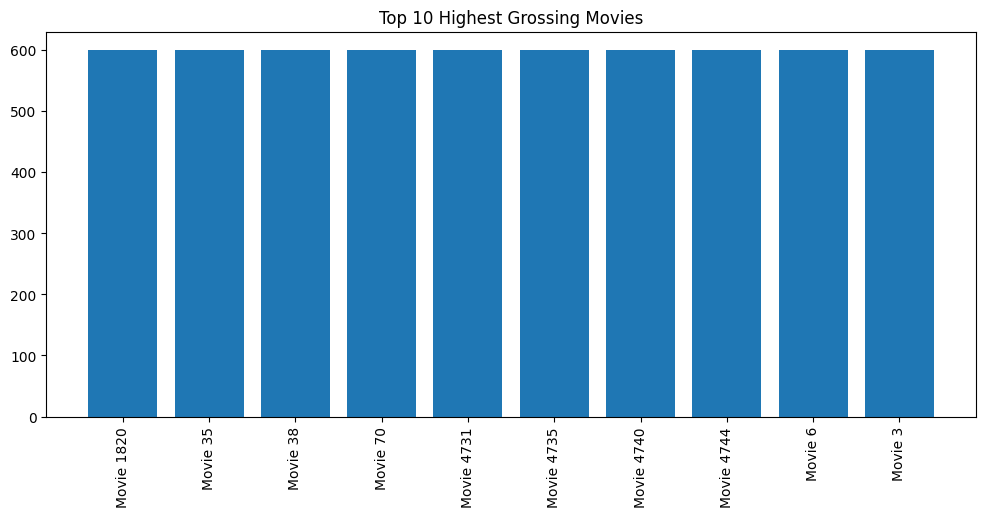

In [92]:
import matplotlib.pyplot as plt

top10 = top_gross.head(10)

plt.figure(figsize=(12,5))

plt.bar(top10['title'],
        top10['gross_million'])

plt.xticks(rotation=90)

plt.title("Top 10 Highest Grossing Movies")

plt.show()

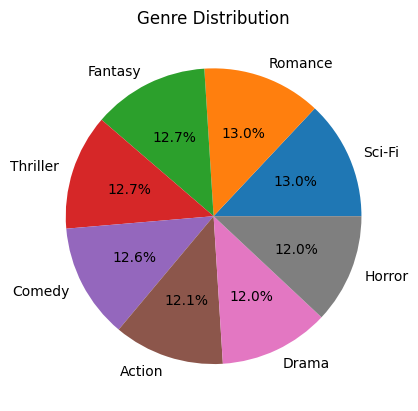

In [93]:
plt.pie(
    genre_count,
    labels=genre_count.index,
    autopct='%1.1f%%'
)

plt.title("Genre Distribution")
plt.show()

In [23]:
top_rated = df.sort_values(
    by='rating',
    ascending=False
)

top_rated[['title','rating']].head(10)

,title,rating
40,Movie 41,9.5
2232,Movie 2233,9.5
3839,Movie 3840,9.5
5273,Movie 5274,9.5
4280,Movie 4281,9.5
2418,Movie 2419,9.5
4748,Movie 4749,9.5
3671,Movie 3672,9.5
3882,Movie 3883,9.5
1821,Movie 1822,9.5


<Figure size 1200x500 with 0 Axes>

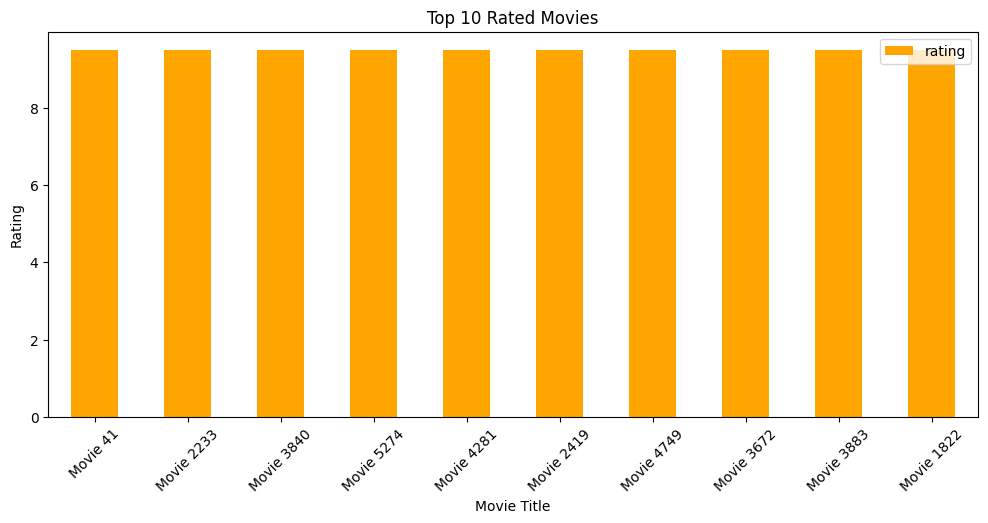

In [94]:
plt.figure(figsize=(12,5))

top_rated.head(10).plot(
    x='title',
    y='rating',
    kind='bar',
    color='orange',
    figsize=(12,5)
)

plt.title("Top 10 Rated Movies")
plt.xlabel("Movie Title")
plt.ylabel("Rating")
plt.xticks(rotation=45)

plt.show()

In [25]:
genre_count = df['genre'].value_counts()

print(genre_count)

genre
Sci-Fi      715
Romance     715
Fantasy     698
Thriller    696
Comedy      691
Action      665
Drama       661
Horror      659
Name: count, dtype: int64


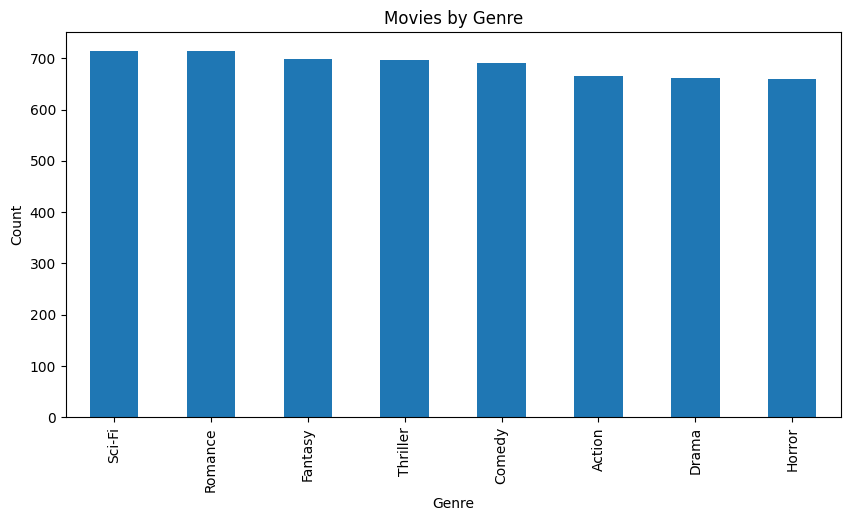

In [26]:
genre_count.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Movies by Genre")

plt.xlabel("Genre")

plt.ylabel("Count")

plt.show()

In [27]:
top_directors = df.groupby(
    'director'
)['gross_million'].sum()

top_directors = top_directors.sort_values(
    ascending=False
)

top_directors.head(10)

director
Rajamouli    183520.0
Scorsese     175380.0
Cameron      173030.0
Nolan        166700.0
Spielberg    165120.0
Tarantino    156370.0
Name: gross_million, dtype: float64

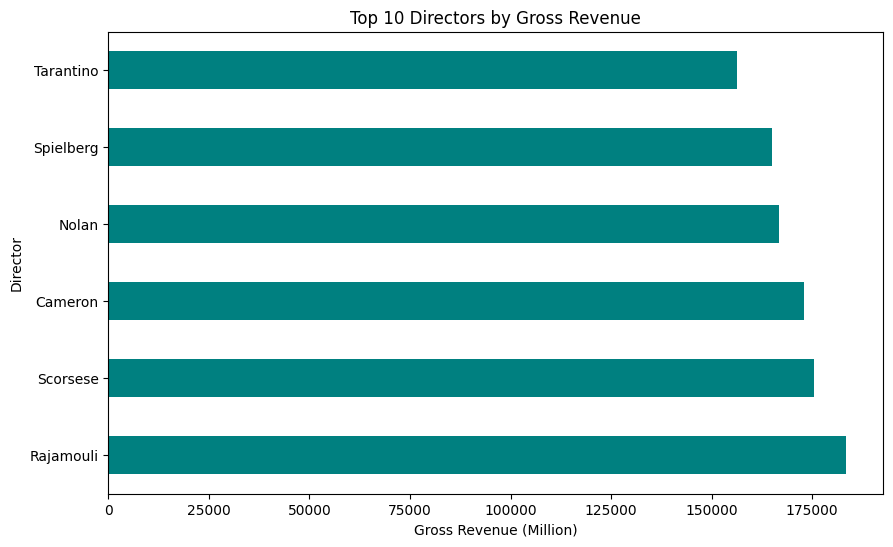

In [95]:
plt.figure(figsize=(10,6))

top_directors.head(10).plot(
    kind='barh',
    color='teal',
    figsize=(10,6)
)

plt.title("Top 10 Directors by Gross Revenue")
plt.xlabel("Gross Revenue (Million)")
plt.ylabel("Director")

plt.show()

In [29]:
top_actors = df.groupby(
    'lead_actor'
)['gross_million'].sum()

top_actors = top_actors.sort_values(
    ascending=False
)

top_actors.head(10)

lead_actor
Actor B    209650.0
Actor E    204460.0
Actor C    200130.0
Actor D    197180.0
Actor A    184830.0
Name: gross_million, dtype: float64

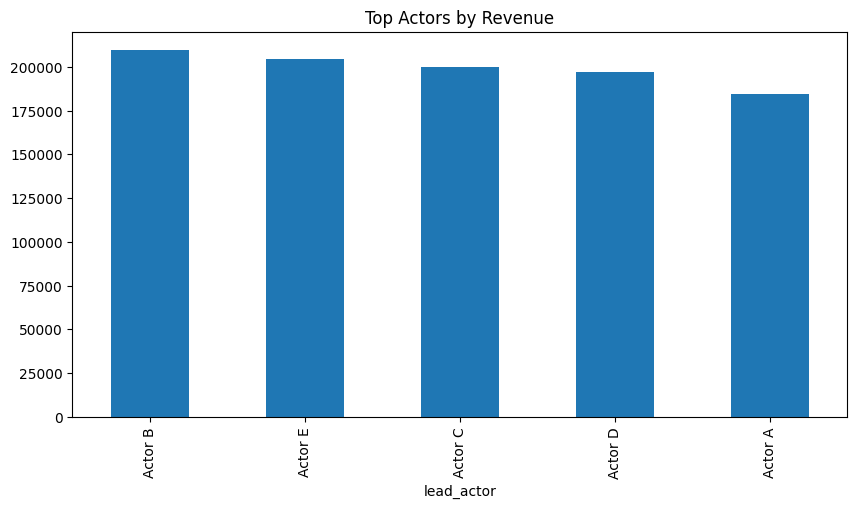

In [30]:
top_actors.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Actors by Revenue")

plt.show()

In [31]:
df['profit'] = (
    df['gross_million']
    - df['budget_million']
)

df[['title',
    'budget_million',
    'gross_million',
    'profit']].head()

,title,budget_million,gross_million,profit
0,Movie 1,100.0,150.0,50.0
1,Movie 2,150.0,150.0,0.0
2,Movie 3,30.0,600.0,570.0
3,Movie 4,100.0,600.0,500.0
4,Movie 5,10.0,600.0,590.0


In [32]:
profit_movies = df.sort_values(
    by='profit',
    ascending=False
)

profit_movies[['title',
               'profit']].head(10)

,title,profit
3332,Movie 3333,590.0
5300,Movie 5301,590.0
3314,Movie 3315,590.0
3865,Movie 3866,590.0
370,Movie 371,590.0
4372,Movie 4373,590.0
4359,Movie 4360,590.0
2265,Movie 2266,590.0
1625,Movie 1626,590.0
4620,Movie 4621,590.0


In [33]:
df['ROI'] = (
    df['profit']
    / df['budget_million']
)

df[['title','ROI']].head()

,title,ROI
0,Movie 1,0.5
1,Movie 2,0.0
2,Movie 3,19.0
3,Movie 4,5.0
4,Movie 5,59.0


In [34]:
df.sort_values(
    by='ROI',
    ascending=False
)[['title','ROI']].head(10)

,title,ROI
3314,Movie 3315,59.0
844,Movie 845,59.0
2608,Movie 2609,59.0
1793,Movie 1794,59.0
370,Movie 371,59.0
4620,Movie 4621,59.0
4611,Movie 4612,59.0
4610,Movie 4611,59.0
2542,Movie 2543,59.0
2697,Movie 2698,59.0


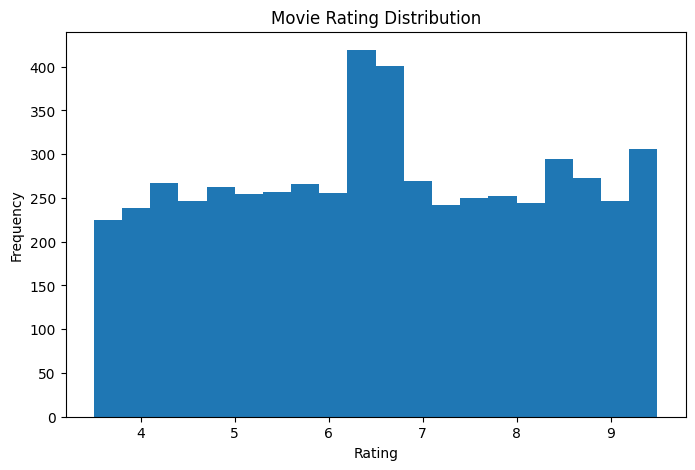

In [101]:
plt.figure(figsize=(8,5))

plt.hist(df['rating'],
         bins=20)

plt.title("Movie Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("Frequency")

plt.show()


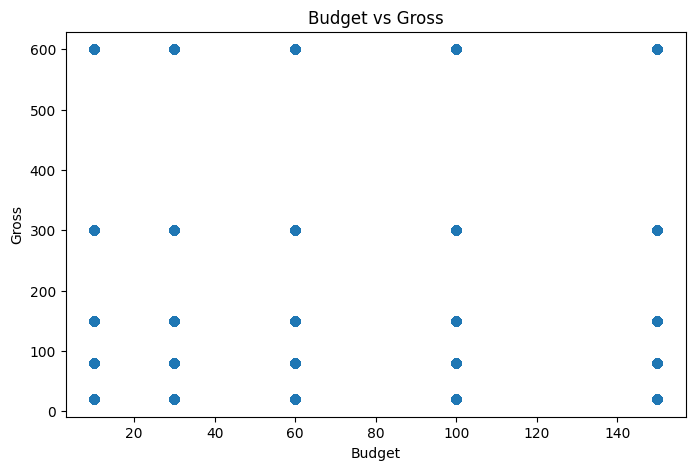

In [36]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['budget_million'],
    df['gross_million']
)

plt.xlabel("Budget")

plt.ylabel("Gross")

plt.title("Budget vs Gross")

plt.show()

In [37]:
corr = df[['budget_million',
           'gross_million',
           'rating']].corr()

print(corr)

                budget_million  gross_million    rating
budget_million        1.000000       0.006373 -0.010113
gross_million         0.006373       1.000000 -0.021434
rating               -0.010113      -0.021434  1.000000


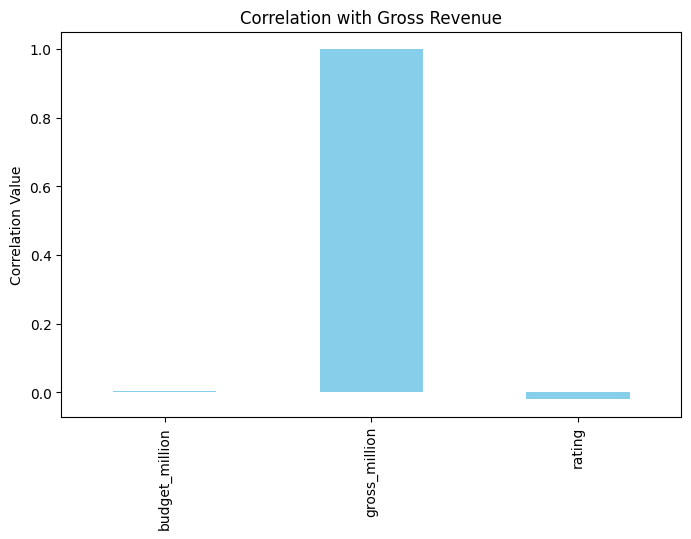

In [102]:
corr = df[['budget_million',
           'gross_million',
           'rating']].corr()

corr['gross_million'].plot(
    kind='bar',
    color='skyblue',
    figsize=(8,5)
)

plt.title("Correlation with Gross Revenue")
plt.ylabel("Correlation Value")

plt.show()

In [39]:
yearly_movies = df.groupby(
    'release_year'
).size()

yearly_movies

release_year
2015.0    598
2016.0    635
2017.0    625
2018.0    605
2019.0    614
2020.0    571
2021.0    614
2022.0    624
dtype: int64

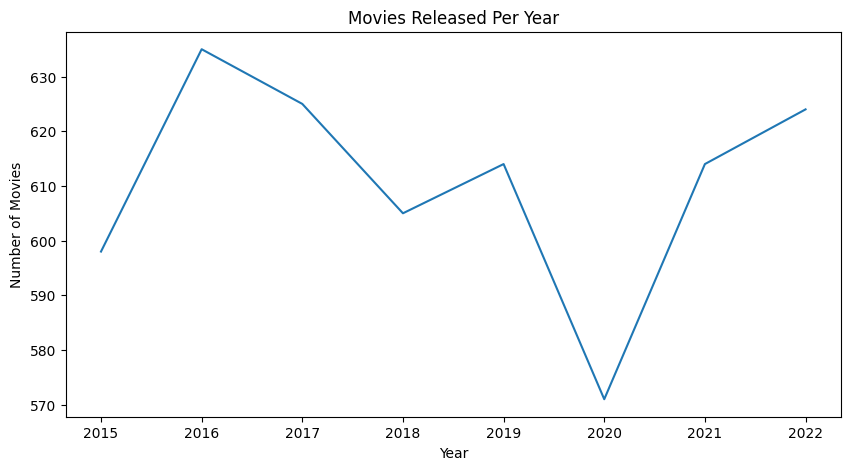

In [40]:
yearly_movies.plot(
    kind='line',
    figsize=(10,5)
)

plt.title("Movies Released Per Year")

plt.xlabel("Year")

plt.ylabel("Number of Movies")

plt.show()

In [41]:
df.to_csv(
    "imdb_cleaned.csv",
    index=False
)

In [42]:
%pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
import pandas as pd
import mysql.connector

In [44]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="mysql@123"
)

cursor = conn.cursor()

print("Connected Successfully")

Connected Successfully


In [45]:
cursor.execute("CREATE DATABASE IF NOT EXISTS imdb_db")

In [46]:
cursor.execute("USE imdb_db")

In [47]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS movies (
    movie_id INT,
    title VARCHAR(255),
    genre VARCHAR(100),
    rating FLOAT,
    budget_million FLOAT,
    gross_million FLOAT,
    director VARCHAR(255),
    lead_actor VARCHAR(255),
    release_year INT
)
""")

In [48]:
for row in df.itertuples(index=False):

    sql = """
    INSERT INTO movies
    VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s)
    """

    values = (
        row.movie_id,
        row.title,
        row.genre,
        row.rating,
        row.budget_million,
        row.gross_million,
        row.director,
        row.lead_actor,
        row.release_year
    )

    cursor.execute(sql, values)

conn.commit()

print("Data Inserted Successfully")

Data Inserted Successfully


In [49]:
cursor.execute("SELECT COUNT(*) FROM movies")

print(cursor.fetchone())

(5500,)


In [50]:
!git --version

git version 2.45.1.windows.1


In [51]:
import os
print(os.getcwd())

C:\Users\mdsuh\AppData\Local\Programs\Python\Python312\Scripts


In [52]:
!git init

Initialized empty Git repository in C:/Users/mdsuh/AppData/Local/Programs/Python/Python312/Scripts/.git/


In [53]:
!git config --global user.name "Mohamad Suhan"
!git config --global user.email "mdsuhanms2@gmail.com"

In [55]:
!git add .

In [58]:
!git remote add origin https://github.com/mohamadsuhan/IMDB-Movie-Dataset-Analysis---P1.git

In [65]:
%%writefile .gitignore
.ipynb_checkpoints/
*.exe
*.dll
*.lnk
__pycache__/

Writing .gitignore


In [66]:
!git add .
!git commit -m "Clean repository remove unnecessary files"
!git push

[main e2fce8f] Clean repository remove unnecessary files
 54 files changed, 305 insertions(+), 6884 deletions(-)
 create mode 100644 .gitignore
 delete mode 100644 .ipynb_checkpoints/Project1-checkpoint.ipynb
 delete mode 100644 .ipynb_checkpoints/Untitled-checkpoint.ipynb
 delete mode 100644 .ipynb_checkpoints/Untitled1-checkpoint.ipynb
 delete mode 100644 .ipynb_checkpoints/customers (2)-checkpoint.csv
 delete mode 100644 .ipynb_checkpoints/etl_mysql_pandas (2)-checkpoint.ipynb
 delete mode 100644 .ipynb_checkpoints/imdb_movies-checkpoint.csv
 delete mode 100644 .ipynb_checkpoints/untitled-checkpoint.py
 delete mode 100644 .ipynb_checkpoints/untitled1-checkpoint.py
 delete mode 100644 Untitled.ipynb
 delete mode 100644 Untitled1.ipynb
 delete mode 100644 customers (2).csv
 delete mode 100644 debugpy-adapter.exe
 delete mode 100644 debugpy.exe
 delete mode 100644 etl_mysql_pandas (2).ipynb
 delete mode 100644 f2py.exe
 delete mode 100644 fonttools.exe
 delete mode 100644 httpx.exe
 de

To https://github.com/mohamadsuhan/IMDB-Movie-Dataset-Analysis---P1.git
   2ad6017..e2fce8f  main -> main


In [103]:
len(df)

5473

In [110]:
df

,movie_id,title,genre,rating,budget_million,gross_million,director,lead_actor,release_year
0,1.0,Movie 1,Thriller,4.2,100.0,NaN,Cameron,NaN,2017.0
1,2.0,Movie 2,Sci-Fi,7.8,150.0,150.0,Nolan,Actor B,2019.0
2,3.0,Movie 3,Thriller,4.9,30.0,600.0,Spielberg,Actor D,2016.0
3,4.0,Movie 4,Thriller,9.1,100.0,600.0,Rajamouli,Actor D,2015.0
4,5.0,Movie 5,Sci-Fi,4.5,10.0,600.0,Cameron,Actor C,2022.0
...,...,...,...,...,...,...,...,...,...
5495,5496.0,Movie 5496,Horror,8.0,NaN,80.0,Scorsese,Actor D,2021.0
5496,5497.0,Movie 5497,Sci-Fi,7.4,30.0,20.0,Cameron,Actor C,2016.0
5497,5498.0,Movie 5498,Sci-Fi,8.6,30.0,80.0,Spielberg,Actor A,2021.0
5498,5499.0,Movie 5499,Fantasy,6.3,10.0,600.0,Spielberg,Actor B,2019.0


In [111]:
df["director"]=df["director"].fillna("unknown")
df["lead_actor"]=df["lead_actor"].fillna("unknown")
df

,movie_id,title,genre,rating,budget_million,gross_million,director,lead_actor,release_year
0,1.0,Movie 1,Thriller,4.2,100.0,NaN,Cameron,unknown,2017.0
1,2.0,Movie 2,Sci-Fi,7.8,150.0,150.0,Nolan,Actor B,2019.0
2,3.0,Movie 3,Thriller,4.9,30.0,600.0,Spielberg,Actor D,2016.0
3,4.0,Movie 4,Thriller,9.1,100.0,600.0,Rajamouli,Actor D,2015.0
4,5.0,Movie 5,Sci-Fi,4.5,10.0,600.0,Cameron,Actor C,2022.0
...,...,...,...,...,...,...,...,...,...
5495,5496.0,Movie 5496,Horror,8.0,NaN,80.0,Scorsese,Actor D,2021.0
5496,5497.0,Movie 5497,Sci-Fi,7.4,30.0,20.0,Cameron,Actor C,2016.0
5497,5498.0,Movie 5498,Sci-Fi,8.6,30.0,80.0,Spielberg,Actor A,2021.0
5498,5499.0,Movie 5499,Fantasy,6.3,10.0,600.0,Spielberg,Actor B,2019.0


In [112]:
df

,movie_id,title,genre,rating,budget_million,gross_million,director,lead_actor,release_year
0,1.0,Movie 1,Thriller,4.2,100.0,NaN,Cameron,unknown,2017.0
1,2.0,Movie 2,Sci-Fi,7.8,150.0,150.0,Nolan,Actor B,2019.0
2,3.0,Movie 3,Thriller,4.9,30.0,600.0,Spielberg,Actor D,2016.0
3,4.0,Movie 4,Thriller,9.1,100.0,600.0,Rajamouli,Actor D,2015.0
4,5.0,Movie 5,Sci-Fi,4.5,10.0,600.0,Cameron,Actor C,2022.0
...,...,...,...,...,...,...,...,...,...
5495,5496.0,Movie 5496,Horror,8.0,NaN,80.0,Scorsese,Actor D,2021.0
5496,5497.0,Movie 5497,Sci-Fi,7.4,30.0,20.0,Cameron,Actor C,2016.0
5497,5498.0,Movie 5498,Sci-Fi,8.6,30.0,80.0,Spielberg,Actor A,2021.0
5498,5499.0,Movie 5499,Fantasy,6.3,10.0,600.0,Spielberg,Actor B,2019.0
